# 

In [2]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy
def SMD(u1,u2):
    return (u1.nominal_value - u2.nominal_value)/(np.sqrt(u1.std_dev**2 + u2.std_dev**2))

def stru(u, digits=2):
    return (("{:." + str(digits) + "e}").format(u).replace("/","").replace("(","").replace(")","").replace("e-0","e-"))
def printu(u, digits=2):
    print(("{:." + str(digits) + "e}").format(u).replace("/","").replace("(","").replace(")","").replace("e-0","e-"))

In [3]:
# Drehspulenmessgerät als Spannungsmesser
R_B = ufloat(10,1) * 1000 # Abgelesen von den Ringen (in Ohm)


In [4]:
def skt_zu_Spannung(skt): 
    U = skt.nominal_value/200
    err_zeiger = 0.25 * 10**(-6)    # TODO hier könnte man noch genauer ausrechnen, was passiert, wenn der Spannungsteiler nicht ganz ausgeglichen ist
    err_eichspann = U * 0.0002
    err_lin = 0.0025 * 5  #5V als maximale spannung durch eichung bei 500SKT mit 2.5V
    error_Komp = unp.sqrt(err_eichspann **2 + err_lin**2)
    return ufloat(U,error_Komp)

    

In [22]:
R_dm = ufloat(52,0.1) + ufloat(448, 448 * 0.01) # Gesamtwiederstand des Drehmessgeräts (für die Spannungsmessung)

def mA_zu_Spannung(I):
    return I / 1000 * R_dm

I_m_b = ufloat(8,0.3) # in mA
I_R_1 = ufloat(2.1,0.3) # in mA

print(mA_zu_Spannung(I_R_1))

1.05+/-0.15


In [6]:
print(f"Kompensator: Batteriespannnug: {skt_zu_Spannung(ufloat(821.2,0.2))}")
print(f"Kompensator: Spannung 1: {skt_zu_Spannung(ufloat(410.9,0.2))}")
print(f"Kompensator: Spannung 2: {skt_zu_Spannung(ufloat(410.7,0.2))}")
print(F"Berechnete Batteriespannung: {skt_zu_Spannung(ufloat(410.7,0.2)) +skt_zu_Spannung(ufloat(410.9,0.2))}")
print(f"Abweichung: {SMD(skt_zu_Spannung(ufloat(821.2,0.2)),skt_zu_Spannung(ufloat(410.7,0.2)) +skt_zu_Spannung(ufloat(410.9,0.2)))}")

Kompensator: Batteriespannnug: 4.106+/-0.013
Kompensator: Spannung 1: 2.054+/-0.013
Kompensator: Spannung 2: 2.054+/-0.013
Berechnete Batteriespannung: 4.108+/-0.018
Abweichung: -0.09227649889951199


In [7]:
skt_zu_Spannung(ufloat(410.7,0.2))+skt_zu_Spannung(ufloat(410.9,0.2))

4.1080000000000005+/-0.01768721327117418

U_B = mA_zu_Spannung(ufloat(8,0.25))
U_R_1 = mA_zu_Spannung(ufloat(2.10,0.25))
I = ufloat(2.10,0.025)/1000
R_unbekannt = R_dm * ((U_B - U_R_1)/(U_R_1) - 1)
print(U_B, U_R_1,R_unbekannt)
printu(R_unbekannt)
#R_unb = U_B/I - 2 * R_dm
#printu(R_unb)

In [9]:
#a = unp.uarray([3,3,3],[Fehler])

In [10]:
DSMG_2_falsch = unp.uarray([1.6,2,2.4,2.8,3.2,3.6,4,4.4,4.8,5.2,5.6,6,6.4,6.8,7.2,7.6,8],[0.25]*17)
Komp_2_skt = unp.uarray([810.4,807.3,803.3,799,794.8,791,788.2,783.2,779.1,775.5,771.2,768.3,763.8,757.9,754,749.2,744],[0.2]*17)

R_erw_2 = ufloat(23.6,0.04)
R_int = ufloat(448, 448 * 0.01)

print(Komp_2_skt[0])


810.40+/-0.20


In [11]:
DSMG_2_richtig = []

for i in range(len(DSMG_2_falsch)):
    DSMG_2_richtig.append(DSMG_2_falsch[i] * (1 + R_int/R_erw_2))


Komp_2_V = []
print(len(Komp_2_skt))

for a in range(len(Komp_2_skt)):
    Komp_2_V.append(skt_zu_Spannung(Komp_2_skt[a]))





def arrayu_to_uarray(x):
    return unp.uarray([a.nominal_value for a in x],[a.std_dev for a in x])

DSMG_2_richtig = arrayu_to_uarray(DSMG_2_richtig)
Komp_2_V = arrayu_to_uarray(Komp_2_V)

print(DSMG_2_richtig)

17
[31.972881355932202+/-5.0052518817972755
 39.96610169491525+/-5.010581642550255
 47.9593220338983+/-5.0170881055608945
 55.952542372881354+/-5.024766699771458
 63.945762711864404+/-5.033612061052801
 71.93898305084745+/-5.0436180506748185
 79.9322033898305+/-5.054777776211535
 87.92542372881356+/-5.067083614718011
 95.9186440677966+/-5.080527238001781
 103.91186440677966+/-5.095099639799482
 111.90508474576271+/-5.110791164659749
 119.89830508474576+/-5.127591538326357
 127.89152542372881+/-5.145489899410987
 135.88474576271184+/-5.164474832142903
 143.8779661016949+/-5.184534399982991
 151.87118644067795+/-5.205656179892125
 159.864406779661+/-5.227827297048333]


In [12]:
#print(DSMG_2_richtig, Komp_2_V)

/usr/lib/python3.14/site-packages/uncertainties/unumpy/core.py:84: FutureWarning: the uncertainties.unumpy.unumpy_to_numpy_matrix function is deprecated. It will be removed in a future release.
  warn(msg, FutureWarning)


[8.12678077e-05 8.33721582e-03]
8.126780765025487e-05 7.75709569420816e-05
[31.972881355932202+/-5.0052518817972755
 39.96610169491525+/-5.010581642550255
 47.9593220338983+/-5.0170881055608945
 55.952542372881354+/-5.024766699771458
 63.945762711864404+/-5.033612061052801
 71.93898305084745+/-5.0436180506748185
 79.9322033898305+/-5.054777776211535
 87.92542372881356+/-5.067083614718011
 95.9186440677966+/-5.080527238001781
 103.91186440677966+/-5.095099639799482
 111.90508474576271+/-5.110791164659749
 119.89830508474576+/-5.127591538326357
 127.89152542372881+/-5.145489899410987
 135.88474576271184+/-5.164474832142903
 143.8779661016949+/-5.184534399982991
 151.87118644067795+/-5.205656179892125
 159.864406779661+/-5.227827297048333]
[-2.56499694e-03  4.14020747e+00]


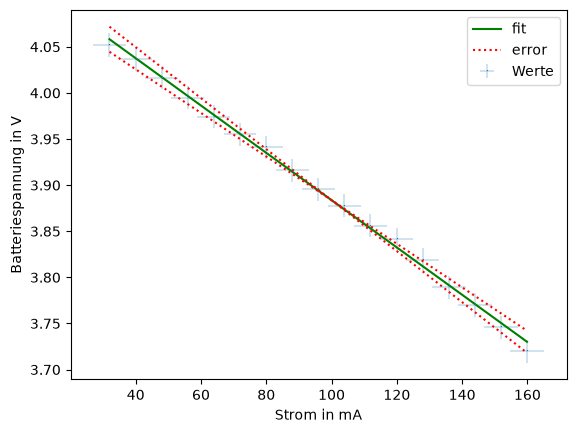

In [13]:
def nom(x):
    return unp.nominal_values(x)
def std(x):
    return unp.std_devs(x)

def lin_func(x,m,b):
    f = m*x+b
    return f
def inv_lin_func (f,m,b):
    x = -(f-b)/m
    return x
    

fit, cov = scipy.optimize.curve_fit(lin_func, nom(DSMG_2_richtig), nom(Komp_2_V), sigma = std(Komp_2_V), absolute_sigma = True)

fit_inv, cov_inv = scipy.optimize.curve_fit(inv_lin_func, nom(Komp_2_V),nom(DSMG_2_richtig), sigma = std(DSMG_2_richtig), absolute_sigma = True)
fit_inv_, cov_inv_ = scipy.optimize.curve_fit(lin_func, nom(Komp_2_V),nom(DSMG_2_richtig), sigma = std(DSMG_2_richtig), absolute_sigma = True)

m_from_inv = 1 / fit_inv_[0]
b_from_inv = -fit_inv_[1]


#print(fit)
perr = np.sqrt(np.diag(cov))
perr_inv = np.sqrt(np.diag(cov_inv))
print(perr_inv)
#print(std(Komp_2_V))
error_m = unp.sqrt(perr_inv[0]**2 + perr[0]**2)

print(perr_inv[0], perr[0])
print(DSMG_2_richtig)
d_m = 0.0002
d_b = 0.02
print(fit)
plt.errorbar(nom(DSMG_2_richtig),nom(Komp_2_V),xerr = std(DSMG_2_richtig),yerr =std(Komp_2_V),fmt = ",", label = "Werte", linewidth = 0.3)
#plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),m_from_inv, b_from_inv))
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0],fit[1]), label = "fit", color = "green")
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0]+d_m,fit[1]-d_b),linestyle = "dotted", color = "red", label = "error")
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0]-d_m,fit[1]+d_b), linestyle = "dotted", color = "red")
plt.xlabel("Strom in mA")
plt.ylabel("Batteriespannung in V")
plt.legend()
plt.savefig("Plot.svg")

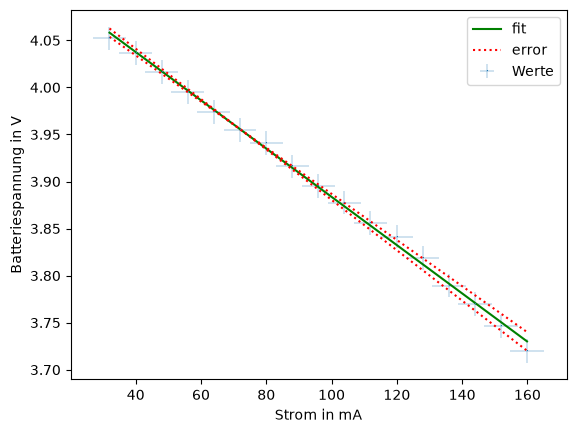

In [14]:
plt.errorbar(nom(DSMG_2_richtig),nom(Komp_2_V),xerr = std(DSMG_2_richtig),yerr =std(Komp_2_V),fmt = ",", label = "Werte", linewidth = 0.3)
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0],fit[1]), label = "fit", color = "green")
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0]+error_m,fit[1]-perr[1]),linestyle = "dotted", color = "red", label = "error")
plt.plot(nom(DSMG_2_richtig),lin_func(nom(DSMG_2_richtig),fit[0]-error_m,fit[1]+perr[1]), linestyle = "dotted", color = "red")
plt.xlabel("Strom in mA")
plt.ylabel("Batteriespannung in V")
plt.legend()

In [15]:

steigung = ufloat(fit[0],perr_inv[0])
steigung_corr = ufloat(fit[0],error_m)
print(steigung_corr)
print(steigung)






-0.00256+/-0.00011
-0.00256+/-0.00008


In [16]:
U_0 = lin_func(0,steigung_corr,ufloat(fit[1],perr_inv[1]))
U_0, fit[1], perr_inv[1]

/usr/lib/python3.14/site-packages/uncertainties/core.py:526: FutureWarning: AffineScalarFunc.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by AffineScalarFunc.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/usr/lib/python3.14/site-packages/uncertainties/core.py:491: FutureWarning: AffineScalarFunc.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


(4.140207465491975+/-0.008337215824759579,
 np.float64(4.140207465491975),
 np.float64(0.008337215824759579))

In [17]:
# Fehlerreichnung für Parallelschaltung
R_d = ufloat(448,5)
R_e = ufloat(23.6,0.04)
printu(R_d/R_e)
printu(ufloat(0,0.25) * (1 + R_d/R_e))


1.90+-0.02e+01
0.00+-5.00e+00


In [18]:
U_Max = U_0 / 2
U_Max

2.0701037327459875+/-0.004168607912379789